Columns in Train Dataset:
['Protocol', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Fwd Packets Length Total', 'Bwd Packets Length Total', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Packet Length Min', 'Packet Length Max', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'CWE Flag Count', 'EC

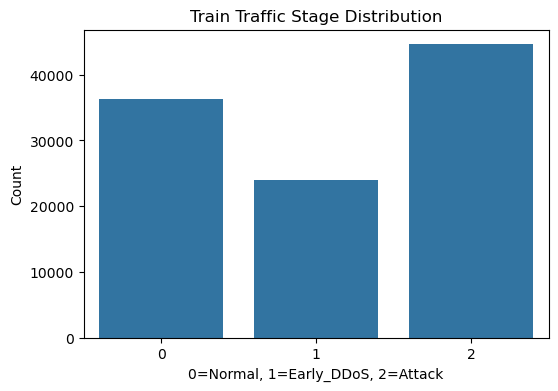


Final Train Label Distribution:
Stage_Label
2    44631
0    36354
1    24028
Name: count, dtype: int64

Final Test Label Distribution:
Stage_Label
2    12096
1     6509
0     5564
Name: count, dtype: int64

Scaling done successfully!


In [1]:
# Data Loading, Preprocessing and Feature Engineering for DDoS Detection
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

train_files = [
    "Syn-training.parquet",
    "UDP-training.parquet",
    "LDAP-training.parquet",
    "MSSQL-training.parquet"
]

test_files = [
    "Syn-testing.parquet",
    "UDP-testing.parquet",
    "LDAP-testing.parquet",
    "MSSQL-testing.parquet"
]

df_train = pd.concat([pd.read_parquet(f) for f in train_files], ignore_index=True)
df_test  = pd.concat([pd.read_parquet(f) for f in test_files], ignore_index=True)

print("Columns in Train Dataset:")
print(df_train.columns.tolist())

print("\nColumns in Test Dataset:")
print(df_test.columns.tolist())

print("Train dataset shape:", df_train.shape)
print("Test dataset shape :", df_test.shape)

print("\nTrain Label Distribution:")
print(df_train["Label"].value_counts())

print("\nTest Label Distribution:")
print(df_test["Label"].value_counts())


def clean_data(df):
    df = df.drop_duplicates()
    df = df.replace([np.inf, -np.inf], np.nan)
    df = df.dropna()
    return df

df_train = clean_data(df_train)
df_test  = clean_data(df_test)

print("\nAfter cleaning Train shape:", df_train.shape)
print("After cleaning Test shape :", df_test.shape)


df_train["Binary_Label"] = df_train["Label"].str.lower().apply(lambda x: 0 if x == "benign" else 1)
df_test["Binary_Label"]  = df_test["Label"].str.lower().apply(lambda x: 0 if x == "benign" else 1)

print("\nTrain Binary Label Distribution:")
print(df_train["Binary_Label"].value_counts())

print("\nTest Binary Label Distribution:")
print(df_test["Binary_Label"].value_counts())

df_train = df_train.reset_index(drop=True)
df_test  = df_test.reset_index(drop=True)

df_train["Time_Index"] = df_train.index
df_test["Time_Index"]  = df_test.index

train_time_index = df_train["Time_Index"].reset_index(drop=True)
test_time_index  = df_test["Time_Index"].reset_index(drop=True)


traffic_features = [
    'Flow Packets/s','Flow Bytes/s','Total Fwd Packets','Total Backward Packets',
    'Fwd Packets/s','Bwd Packets/s','Down/Up Ratio'
]

duration_features = [
    'Flow Duration','Active Mean','Active Std','Active Max','Active Min',
    'Idle Mean','Idle Std','Idle Max','Idle Min'
]

iat_features = [
    'Flow IAT Mean','Flow IAT Std','Flow IAT Max','Flow IAT Min',
    'Fwd IAT Mean','Fwd IAT Std','Bwd IAT Mean','Bwd IAT Std'
]

tcp_flag_features = [
    'SYN Flag Count','ACK Flag Count','RST Flag Count','PSH Flag Count','FIN Flag Count'
]

packet_features = [
    'Packet Length Mean','Packet Length Std','Packet Length Variance',
    'Packet Length Min','Packet Length Max','Avg Packet Size',
    'Avg Fwd Segment Size','Avg Bwd Segment Size'
]

subflow_features = [
    'Subflow Fwd Packets','Subflow Fwd Bytes',
    'Subflow Bwd Packets','Subflow Bwd Bytes'
]

selected_features = (
    traffic_features + duration_features + iat_features +
    tcp_flag_features + packet_features + subflow_features
)

selected_features = [f for f in selected_features if f in df_train.columns]

print("\nTotal Selected Features:", len(selected_features))


def create_stage_labels(df, early_ratio=0.20):
    df = df.copy()
    df["Stage_Label"] = 0

    # Mark all attacks as Attack initially
    df.loc[df["Binary_Label"] == 1, "Stage_Label"] = 2

    for attack_type in df[df["Binary_Label"] == 1]["Label"].unique():
        
        idx = df[(df["Binary_Label"] == 1) & (df["Label"] == attack_type)] \
                .sort_values("Time_Index").index

        split_point = int(len(idx) * early_ratio)

        early_idx = idx[:split_point]

        df.loc[early_idx, "Stage_Label"] = 1

    return df

df_train = create_stage_labels(df_train, early_ratio=0.35)
df_test  = create_stage_labels(df_test, early_ratio=0.35)

print("\nTrain Stage Label Distribution:")
print(df_train["Stage_Label"].value_counts())

print("\nTest Stage Label Distribution:")
print(df_test["Stage_Label"].value_counts())

plt.figure(figsize=(6,4))
sns.countplot(x="Stage_Label", data=df_train)
plt.title("Train Traffic Stage Distribution")
plt.xlabel("0=Normal, 1=Early_DDoS, 2=Attack")
plt.ylabel("Count")
plt.show()

X_train_raw = df_train[selected_features].copy()
y_train_raw = df_train["Stage_Label"].copy()

X_test_raw  = df_test[selected_features].copy()
y_test_raw  = df_test["Stage_Label"].copy()

print("\nFinal Train Label Distribution:")
print(y_train_raw.value_counts())

print("\nFinal Test Label Distribution:")
print(y_test_raw.value_counts())

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled  = scaler.transform(X_test_raw)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=selected_features)
X_test_scaled  = pd.DataFrame(X_test_scaled, columns=selected_features)

y_train_raw = y_train_raw.reset_index(drop=True)
y_test_raw  = y_test_raw.reset_index(drop=True)

print("\nScaling done successfully!")


In [2]:
df_train.head()

,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Fwd Packets Length Total,Bwd Packets Length Total,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,Binary_Label,Time_Index,Stage_Label
0,6,105,2,2,12.0,12.0,6.0,6.0,6.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,Syn,1,0,1
1,6,1,2,0,12.0,0.0,6.0,6.0,6.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,Syn,1,1,1
2,6,55295858,8,0,48.0,0.0,6.0,6.0,6.0,0.0,...,1.0,1.0,18431952.0,4641289.0,22000140.0,13184826.0,Syn,1,2,1
3,6,49,2,0,12.0,0.0,6.0,6.0,6.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,Syn,1,3,1
4,6,109,2,2,12.0,12.0,6.0,6.0,6.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,Syn,1,4,1


In [3]:
df_train[selected_features].head(10).to_excel("sample_dataset.xlsx", index=False)

In [4]:
df_test[selected_features].to_csv("streamlit_test_data.csv", index=False)

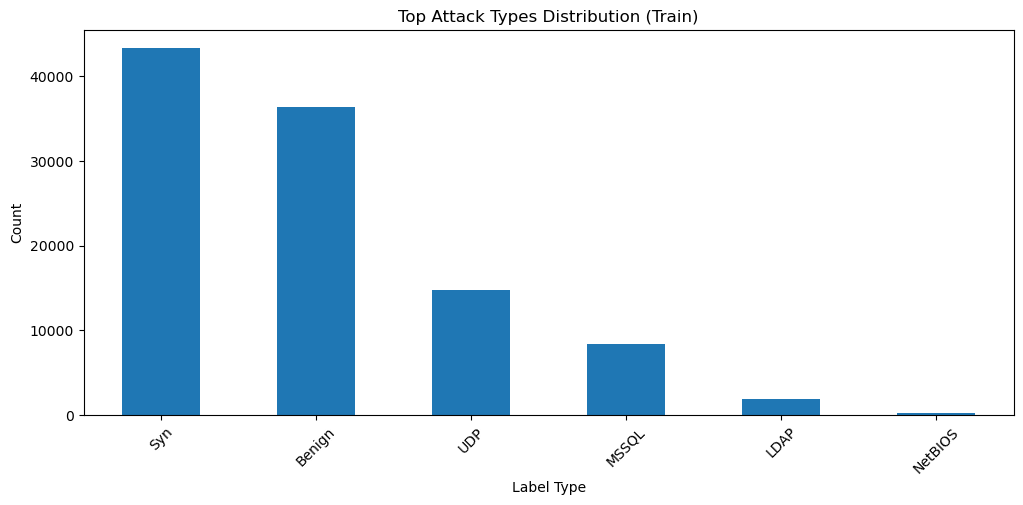

In [5]:
# Label Distribution (Original Attack Types)
plt.figure(figsize=(12,5))
df_train["Label"].value_counts().head(15).plot(kind="bar")
plt.title("Top Attack Types Distribution (Train)") 
plt.xlabel("Label Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

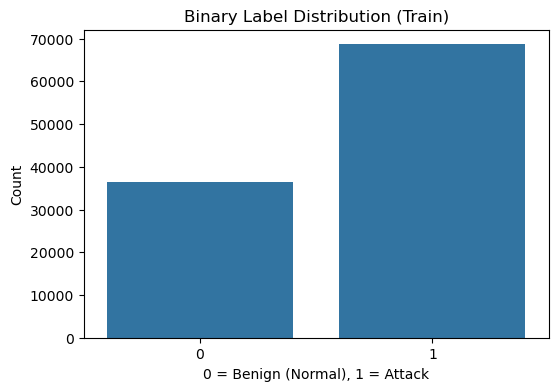

In [6]:
# Binary Label Distribution (Normal vs Attack)
plt.figure(figsize=(6,4))
sns.countplot(x="Binary_Label", data=df_train)
plt.title("Binary Label Distribution (Train)")
plt.xlabel("0 = Benign (Normal), 1 = Attack")
plt.ylabel("Count")
plt.show()


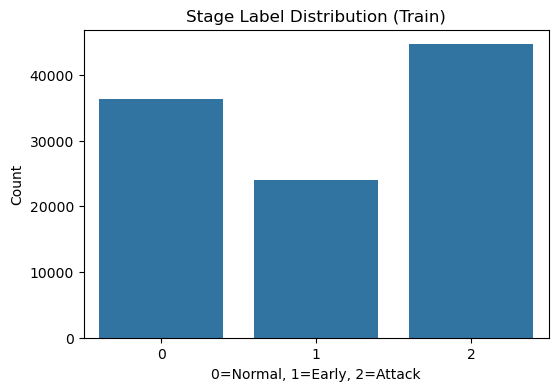

In [7]:
# Stage Label Distribution (Normal vs Early vs Attack)
plt.figure(figsize=(6,4))
sns.countplot(x="Stage_Label", data=df_train)
plt.title("Stage Label Distribution (Train)")
plt.xlabel("0=Normal, 1=Early, 2=Attack")
plt.ylabel("Count")
plt.show()

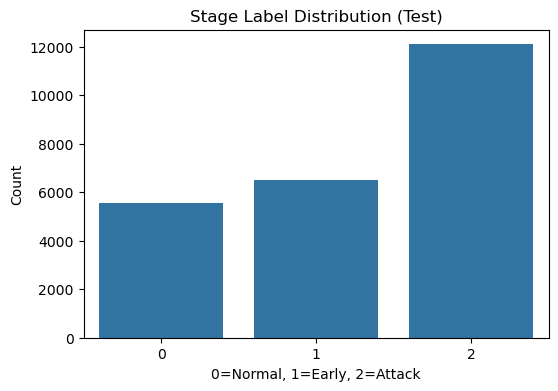

In [8]:
# Stage Label Distribution (Test)
plt.figure(figsize=(6,4))
sns.countplot(x="Stage_Label", data=df_test)
plt.title("Stage Label Distribution (Test)")
plt.xlabel("0=Normal, 1=Early, 2=Attack")
plt.ylabel("Count")
plt.show()

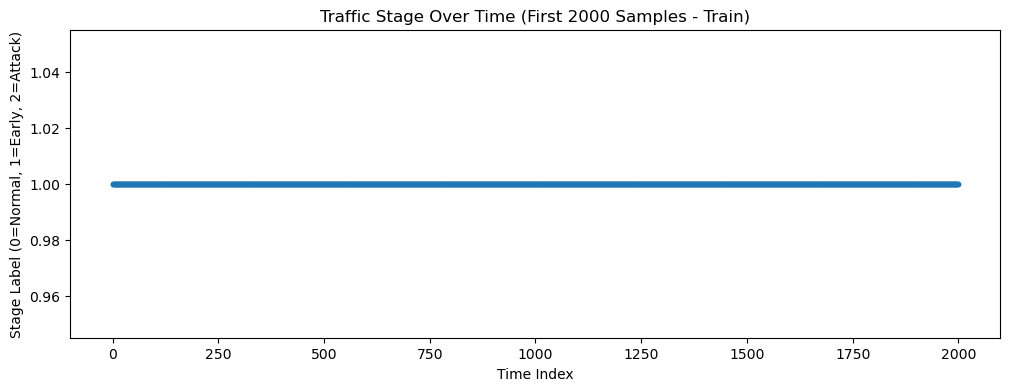

In [9]:
# Time-based Visualization (Stage vs Time)
plt.figure(figsize=(12,4))
plt.plot(df_train["Time_Index"][:2000], df_train["Stage_Label"][:2000], marker=".", linestyle="None")
plt.title("Traffic Stage Over Time (First 2000 Samples - Train)")
plt.xlabel("Time Index")
plt.ylabel("Stage Label (0=Normal, 1=Early, 2=Attack)")
plt.show()

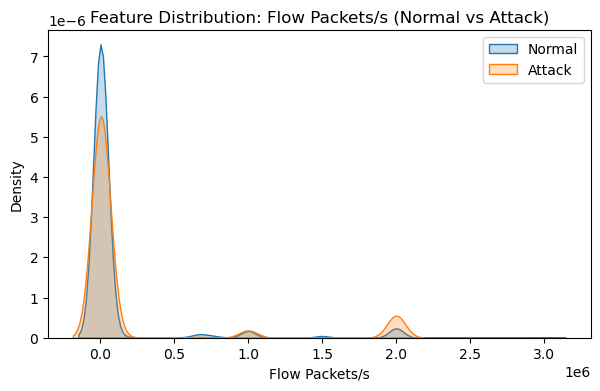

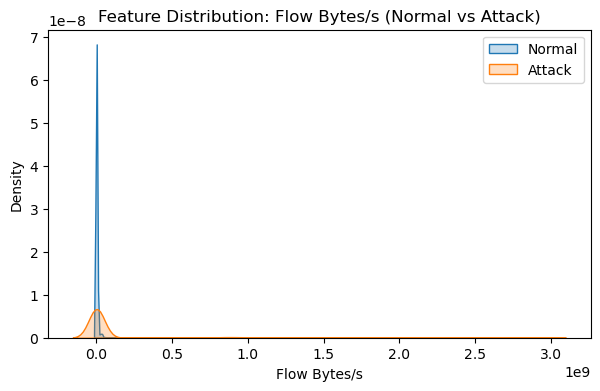

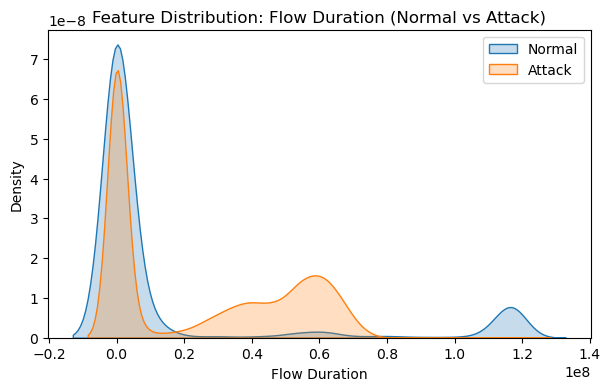

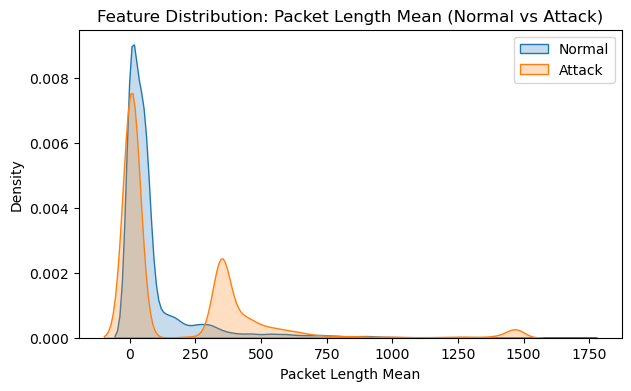

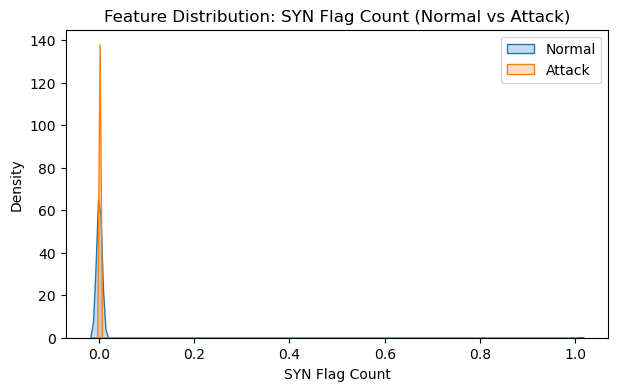

In [10]:
# Feature Distribution Comparison (Normal vs Attack)
important_features = [
    "Flow Packets/s", "Flow Bytes/s", "Flow Duration",
    "Packet Length Mean", "SYN Flag Count"
]

important_features = [f for f in important_features if f in selected_features]

for col in important_features:
    plt.figure(figsize=(7,4))
    sns.kdeplot(df_train[df_train["Binary_Label"]==0][col], label="Normal", fill=True)
    sns.kdeplot(df_train[df_train["Binary_Label"]==1][col], label="Attack", fill=True)
    plt.title(f"Feature Distribution: {col} (Normal vs Attack)")
    plt.xlabel(col)
    plt.legend()
    plt.show()

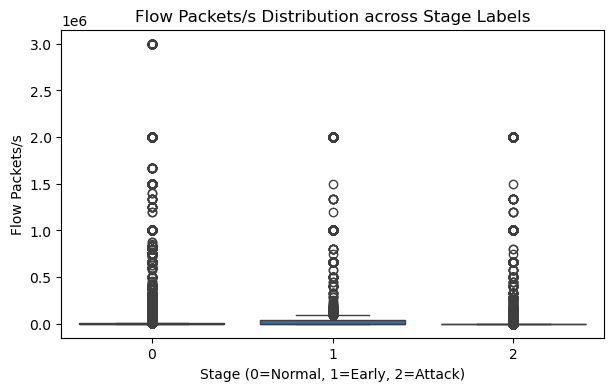

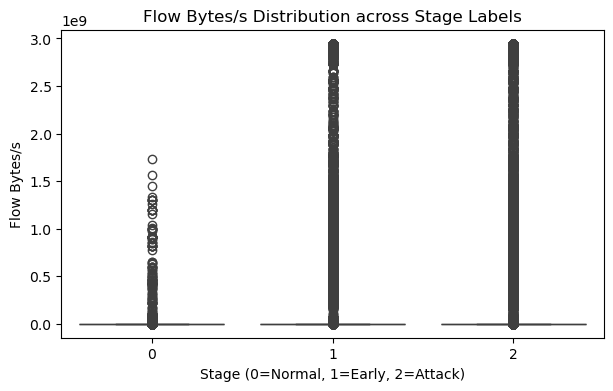

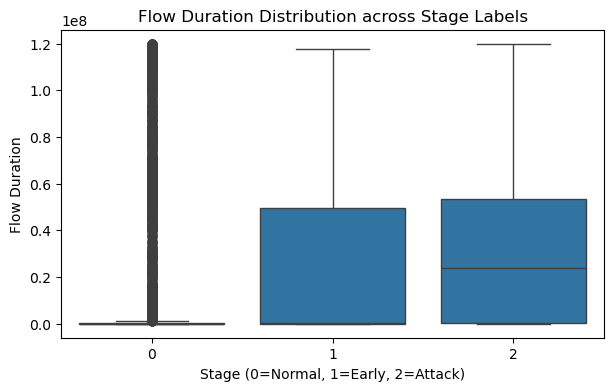

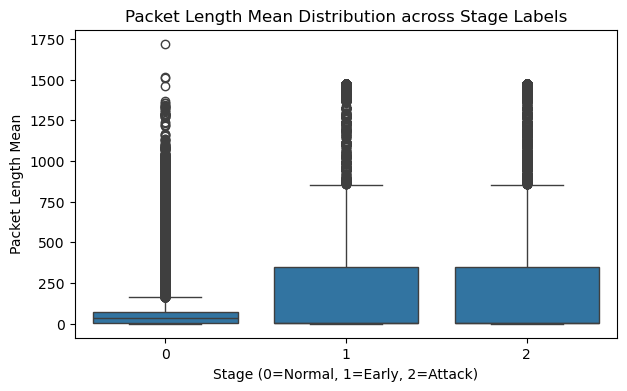

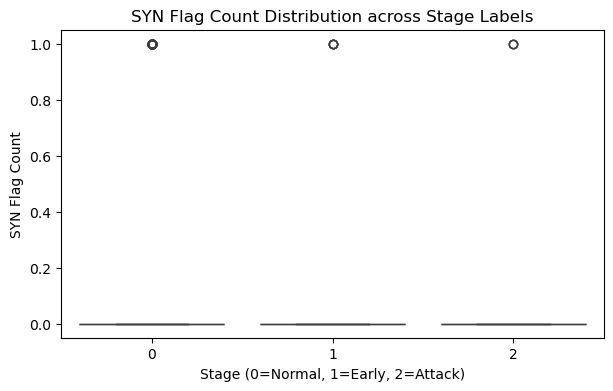

In [11]:
# Boxplot: Stage vs Feature
for col in important_features:
    plt.figure(figsize=(7,4))
    sns.boxplot(x="Stage_Label", y=col, data=df_train)
    plt.title(f"{col} Distribution across Stage Labels")
    plt.xlabel("Stage (0=Normal, 1=Early, 2=Attack)")
    plt.ylabel(col)
    plt.show()

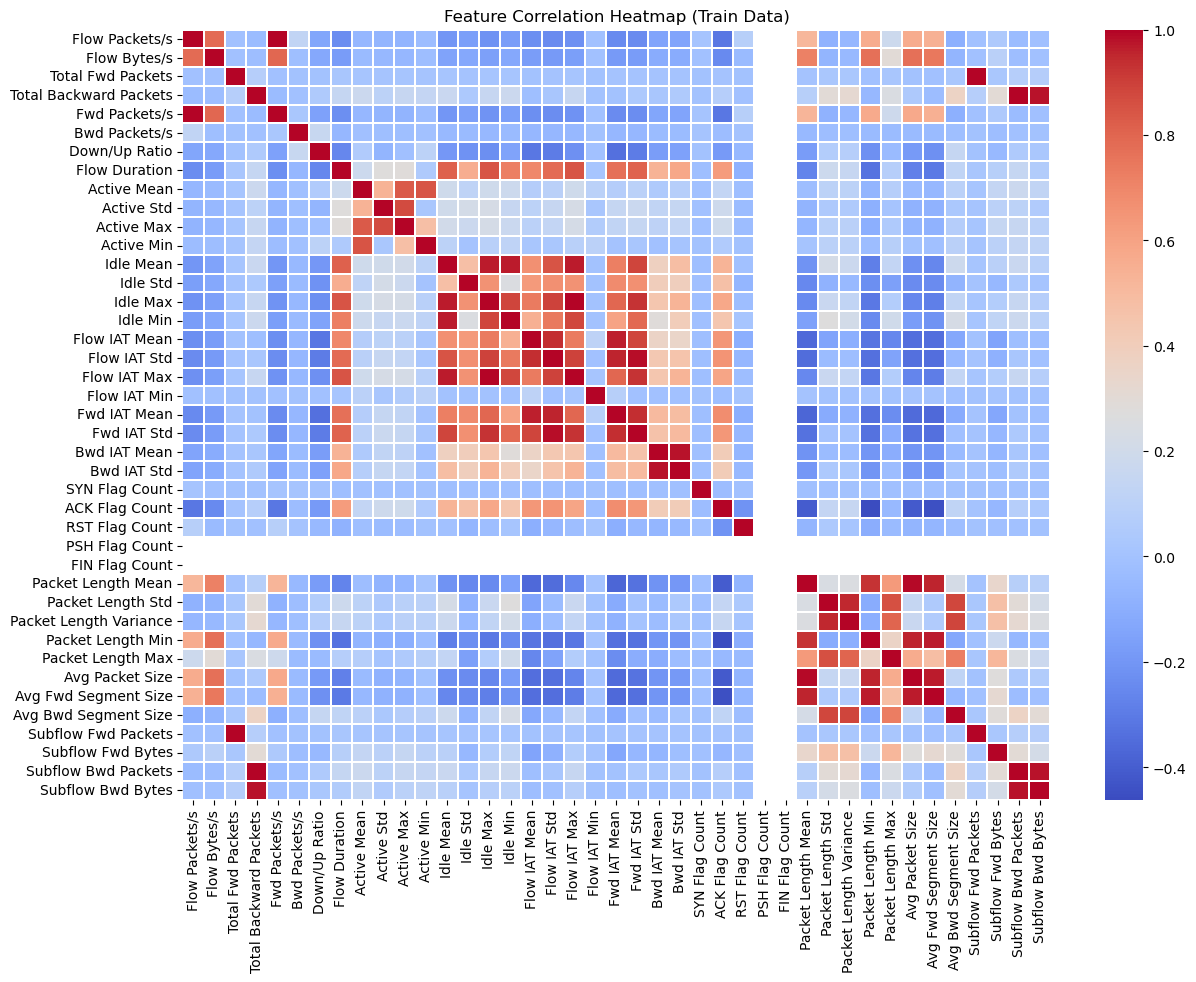

In [12]:
# Correlation Heatmap (Top 20 Features Only)
corr_matrix = df_train[selected_features].corr()

plt.figure(figsize=(14,10))
sns.heatmap(corr_matrix, cmap="coolwarm", linewidths=0.2)
plt.title("Feature Correlation Heatmap (Train Data)")
plt.show()

In [13]:
# Correlation with Target (Stage_Label)
temp_df = df_train[selected_features].copy()
temp_df["Stage_Label"] = df_train["Stage_Label"]

stage_corr = temp_df.corr()["Stage_Label"].sort_values(ascending=False)

print("\nTop 15 Features positively correlated with Stage_Label:")
print(stage_corr.head(15))

print("\nTop 15 Features negatively correlated with Stage_Label:")
print(stage_corr.tail(15))



Top 15 Features positively correlated with Stage_Label:
Stage_Label             1.000000
Fwd IAT Mean            0.374928
Flow IAT Mean           0.366118
ACK Flag Count          0.344500
Flow IAT Std            0.298285
Packet Length Min       0.282587
Fwd IAT Std             0.274806
Idle Std                0.273053
Avg Fwd Segment Size    0.231149
Bwd IAT Mean            0.204222
Avg Packet Size         0.187408
Flow Duration           0.169505
Idle Max                0.168851
Packet Length Mean      0.166267
Bwd IAT Std             0.164494
Name: Stage_Label, dtype: float64

Top 15 Features negatively correlated with Stage_Label:
Subflow Bwd Bytes        -0.046258
Active Mean              -0.048309
Subflow Fwd Bytes        -0.051944
Bwd Packets/s            -0.061138
Total Backward Packets   -0.080219
Subflow Bwd Packets      -0.080219
Active Min               -0.091492
Packet Length Max        -0.156812
Packet Length Variance   -0.248842
RST Flag Count           -0.265987
Avg Bwd

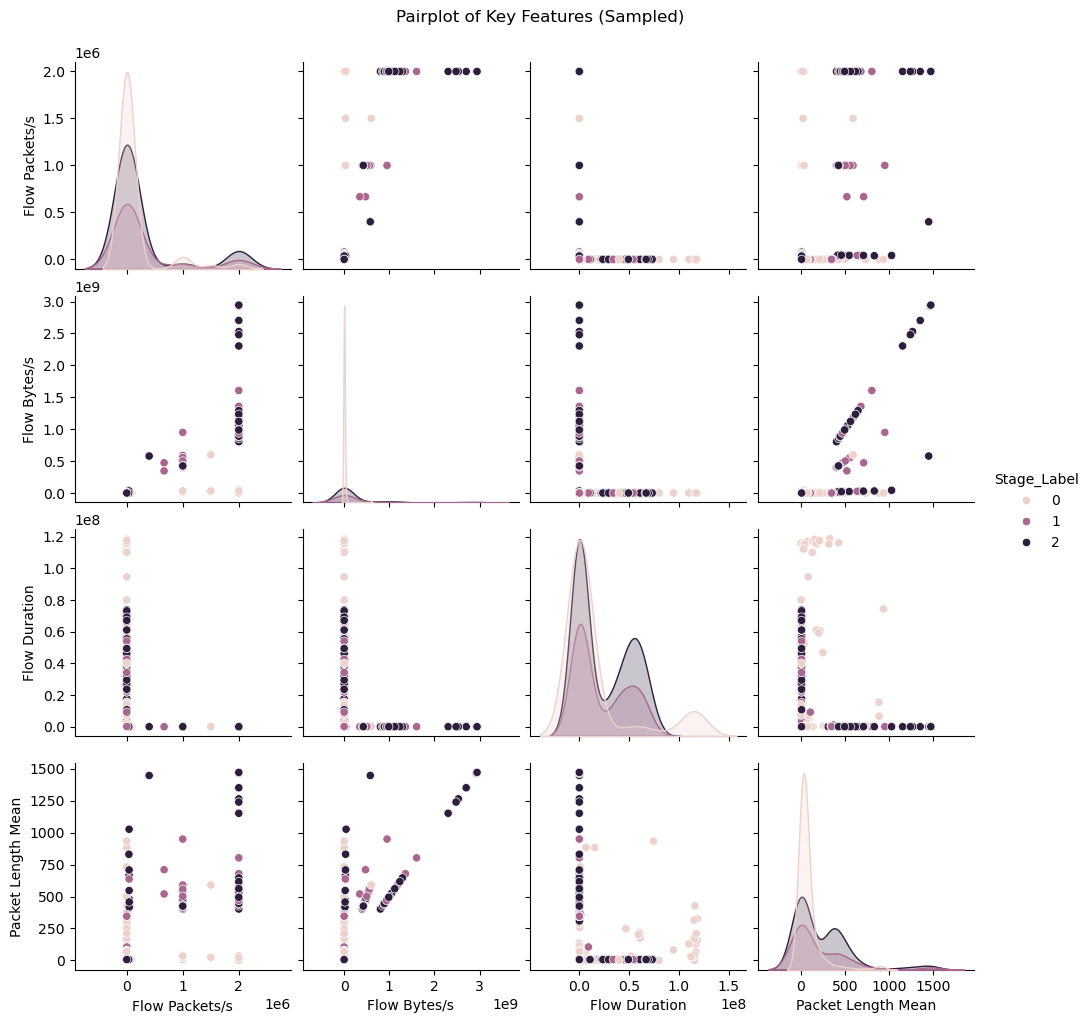

In [14]:
# Pairplot
small_features = important_features[:4] + ["Stage_Label"]

if len(small_features) > 2:
    sns.pairplot(df_train[small_features].sample(500, random_state=42),
                 hue="Stage_Label",
                 diag_kind="kde")
    plt.suptitle("Pairplot of Key Features (Sampled)", y=1.02)
    plt.show()


Train Label Distribution:
Stage_Label
2    40168
0    32718
1    21625
Name: count, dtype: int64

Val Label Distribution:
Stage_Label
2    4463
0    3636
1    2403
Name: count, dtype: int64
Gradient Boosting Validation Results
Validation Accuracy: 0.7675680822700438

Validation Classification Report:

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00      3636
  Early_DDoS       0.49      0.30      0.37      2403
      Attack       0.69      0.83      0.75      4463

    accuracy                           0.77     10502
   macro avg       0.73      0.71      0.71     10502
weighted avg       0.75      0.77      0.75     10502

Gradient Boosting Test Results
Test Accuracy: 0.6829823327402872

Test Classification Report:

              precision    recall  f1-score   support

      Normal       0.91      1.00      0.95      5564
  Early_DDoS       0.42      0.34      0.38      6509
      Attack       0.68      0.72      0.70     12096

  

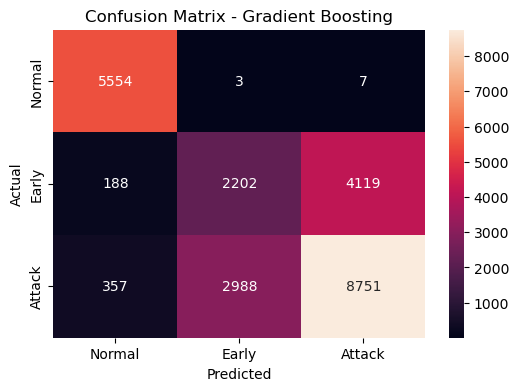

In [16]:
# MODEL 1: Gradient Boosting

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_sample_weight

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

X_train_gb, X_val_gb, y_train_gb, y_val_gb = train_test_split(
    X_train_scaled, y_train_raw,
    test_size=0.1,
    random_state=42,
    stratify=y_train_raw
)

print("\nTrain Label Distribution:")
print(y_train_gb.value_counts())

print("\nVal Label Distribution:")
print(y_val_gb.value_counts())

sample_weights = compute_sample_weight(class_weight="balanced", y=y_train_gb)


gb_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb_model.fit(X_train_gb, y_train_gb, sample_weight=sample_weights)


y_val_pred = gb_model.predict(X_val_gb)


print("Gradient Boosting Validation Results")

print("Validation Accuracy:", accuracy_score(y_val_gb, y_val_pred))

print("\nValidation Classification Report:\n")
print(classification_report(
    y_val_gb, y_val_pred,
    labels=[0, 1, 2],
    target_names=["Normal", "Early_DDoS", "Attack"],
    zero_division=0
))

y_pred_gb = gb_model.predict(X_test_scaled)

print("Gradient Boosting Test Results")

print("Test Accuracy:", accuracy_score(y_test_raw, y_pred_gb))

print("\nTest Classification Report:\n")
print(classification_report(
    y_test_raw, y_pred_gb,
    labels=[0, 1, 2],
    target_names=["Normal", "Early_DDoS", "Attack"],
    zero_division=0
))

cm_gb = confusion_matrix(y_test_raw, y_pred_gb, labels=[0, 1, 2])

plt.figure(figsize=(6, 4))
sns.heatmap(cm_gb, annot=True, fmt="d",
            xticklabels=["Normal", "Early", "Attack"],
            yticklabels=["Normal", "Early", "Attack"])
plt.title("Confusion Matrix - Gradient Boosting")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [17]:
!python -m pip install shap --user

SHAP FEATURE IMPORTANCE - GRADIENT BOOSTING (Multi-Class)


  0%|          | 0/200 [00:00<?, ?it/s]

SHAP values shape: (200, 41, 3)


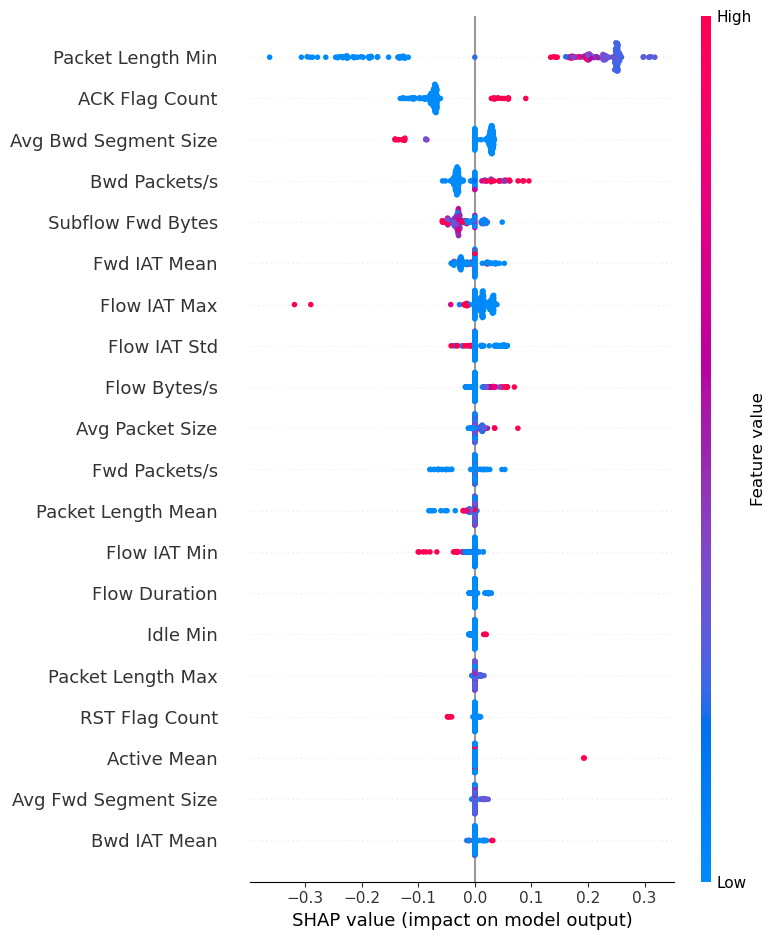

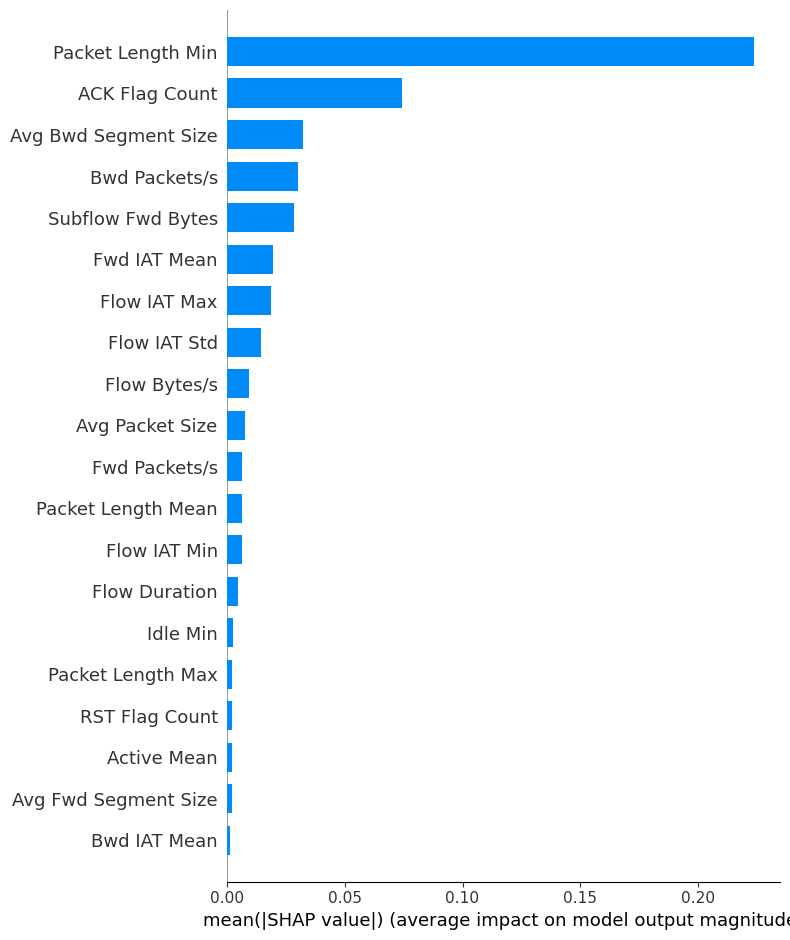

In [18]:
# SHAP FEATURE IMPORTANCE

import shap
import numpy as np
import matplotlib.pyplot as plt

print("SHAP FEATURE IMPORTANCE - GRADIENT BOOSTING (Multi-Class)")

background = X_train_scaled.sample(100, random_state=42)
explainer = shap.KernelExplainer(gb_model.predict_proba, background)
X_sample = X_test_scaled.sample(200, random_state=42)

shap_values = explainer.shap_values(X_sample)
shap_values_array = np.array(shap_values)

print("SHAP values shape:", shap_values_array.shape)

shap_early = shap_values_array[:, :, 1]
shap.summary_plot(shap_early, X_sample)
shap.summary_plot(shap_early, X_sample, plot_type="bar")

MODEL 2: GRU Multi-Class Sequence Model

Train GRU Shape: (104973, 40, 41)
Test GRU Shape : (24129, 40, 41)

Train Final Distribution:
2    0.425171
0    0.346314
1    0.228515
Name: proportion, dtype: float64

Val Final Distribution:
2    0.425129
0    0.346352
1    0.228520
Name: proportion, dtype: float64

Adjusted Class Weights: {np.int64(0): np.float64(0.9625180838274549), np.int64(1): np.float64(1.4586903824478514), np.int64(2): np.float64(1.1759983071101374)}


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ gru (GRU)                            │ (None, 40, 128)             │          65,664 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 40, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gru_1 (GRU)                          │ (None, 64)                  │          37,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 3)                   │             195 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 107,267 (419.01 KB)

 Trainable params: 107,267 (419.01 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
1477/1477 ━━━━━━━━━━━━━━━━━━━━ 112s 72ms/step - accuracy: 0.8329 - loss: 0.4550 - val_accuracy: 0.8532 - val_loss: 0.3162 - learning_rate: 5.0000e-04
Epoch 2/20
1477/1477 ━━━━━━━━━━━━━━━━━━━━ 67s 45ms/step - accuracy: 0.8618 - loss: 0.3893 - val_accuracy: 0.8743 - val_loss: 0.2738 - learning_rate: 5.0000e-04
Epoch 3/20
1477/1477 ━━━━━━━━━━━━━━━━━━━━ 75s 51ms/step - accuracy: 0.8902 - loss: 0.3174 - val_accuracy: 0.9068 - val_loss: 0.2010 - learning_rate: 5.0000e-04
Epoch 4/20
1477/1477 ━━━━━━━━━━━━━━━━━━━━ 78s 53ms/step - accuracy: 0.9211 - loss: 0.2237 - val_accuracy: 0.9322 - val_loss: 0.1503 - learning_rate: 5.0000e-04
Epoch 5/20
1477/1477 ━━━━━━━━━━━━━━━━━━━━ 72s 49ms/step - accuracy: 0.9349 - loss: 0.1836 - val_accuracy: 0.9396 - val_loss: 0.1288 - learning_rate: 5.0000e-04
Epoch 6/20
1477/1477 ━━━━━━━━━━━━━━━━━━━━ 91s 62ms/step - accuracy: 0.9406 - loss: 0.1633 - val_accuracy: 0.9463 - val_loss: 0.1169 - learning_rate: 5.0000e-04
Epoch 7/20
1477/1477 ━━━━━━━━━━━━━━━━━━

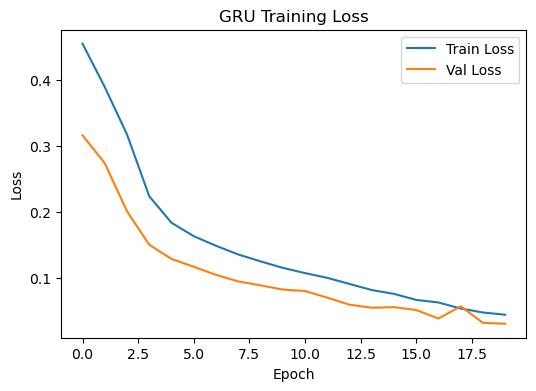

GRU MODEL  TEST RESULTS
GRU Test Accuracy: 0.7503004670143127

Classification Report:

              precision    recall  f1-score   support

      Normal       1.00      0.99      1.00      5564
  Early_DDoS       0.53      0.55      0.54      6469
      Attack       0.75      0.75      0.75     12096

    accuracy                           0.75     24129
   macro avg       0.76      0.76      0.76     24129
weighted avg       0.75      0.75      0.75     24129



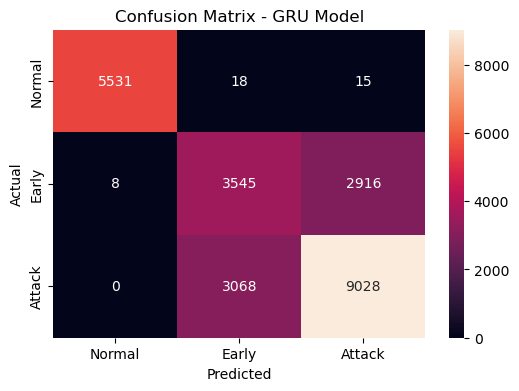

In [19]:
# MODEL 2: GRU Multi-Class

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


print("MODEL 2: GRU Multi-Class Sequence Model")

df_train_sorted = df_train.sort_values("Time_Index").copy()
df_test_sorted  = df_test.sort_values("Time_Index").copy()

X_train_sorted = X_train_scaled.loc[df_train_sorted.index].values.astype(np.float32)
y_train_sorted = df_train_sorted["Stage_Label"].values.astype(int)

X_test_sorted  = X_test_scaled.loc[df_test_sorted.index].values.astype(np.float32)
y_test_sorted  = df_test_sorted["Stage_Label"].values.astype(int)
WINDOW_SIZE = 40

def create_gru_sequences(X, y, window_size=40):
    X_seq, y_seq = [], []
    for i in range(len(X) - window_size):
        X_seq.append(X[i:i+window_size])
        y_seq.append(y[i+window_size])
    return np.array(X_seq), np.array(y_seq)

X_train_seq, y_train_seq = create_gru_sequences(X_train_sorted, y_train_sorted, WINDOW_SIZE)
X_test_seq, y_test_seq   = create_gru_sequences(X_test_sorted, y_test_sorted, WINDOW_SIZE)

print("\nTrain GRU Shape:", X_train_seq.shape)
print("Test GRU Shape :", X_test_seq.shape)

X_train_final, X_val_final, y_train_final, y_val_final = train_test_split(
    X_train_seq, y_train_seq,
    test_size=0.1,
    random_state=42,
    stratify=y_train_seq,
    shuffle=True
)

print("\nTrain Final Distribution:")
print(pd.Series(y_train_final).value_counts(normalize=True))

print("\nVal Final Distribution:")
print(pd.Series(y_val_final).value_counts(normalize=True))

y_train_cat = to_categorical(y_train_final, num_classes=3)
y_val_cat   = to_categorical(y_val_final, num_classes=3)
y_test_cat  = to_categorical(y_test_seq, num_classes=3)

classes = np.unique(y_train_final)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train_final
)

class_weight_dict = dict(zip(classes, class_weights))

# Slight boost to Attack
class_weight_dict[2] = class_weight_dict[2] * 1.5

print("\nAdjusted Class Weights:", class_weight_dict)
gru_model = Sequential([
    Input(shape=(WINDOW_SIZE, X_train_seq.shape[2])),

    GRU(128, return_sequences=True),
    Dropout(0.3),

    GRU(64),
    Dropout(0.3),

    Dense(64, activation="relu"),
    Dropout(0.2),

    Dense(3, activation="softmax")
])

gru_model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

gru_model.summary()
early_stop = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
lr_reduce  = ReduceLROnPlateau(monitor="val_loss", patience=3, factor=0.5, verbose=1)
history_gru = gru_model.fit(
    X_train_final, y_train_cat,
    validation_data=(X_val_final, y_val_cat),
    epochs=20,
    batch_size=64,
    class_weight=class_weight_dict,
    callbacks=[early_stop, lr_reduce],
    shuffle=True,
    verbose=1
)
plt.figure(figsize=(6,4))
plt.plot(history_gru.history['loss'], label="Train Loss")
plt.plot(history_gru.history['val_loss'], label="Val Loss")
plt.title("GRU Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()
test_loss, test_acc = gru_model.evaluate(X_test_seq, y_test_cat, verbose=0)


print("GRU MODEL  TEST RESULTS")
print("GRU Test Accuracy:", test_acc)

probs = gru_model.predict(X_test_seq, verbose=0)

y_pred = np.argmax(probs, axis=1)
y_true = y_test_seq

print("\nClassification Report:\n")
print(classification_report(
    y_true, y_pred,
    labels=[0, 1, 2],
    target_names=["Normal", "Early_DDoS", "Attack"],
    zero_division=0
))

cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=["Normal","Early","Attack"],
            yticklabels=["Normal","Early","Attack"])
plt.title("Confusion Matrix - GRU Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

MULTI-CLASS ROC CURVE (GRU Model)


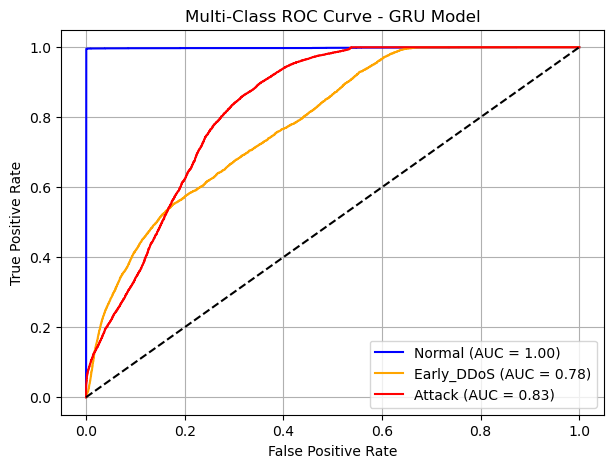


AUC Scores:
Normal AUC: 0.9983
Early_DDoS AUC: 0.7827
Attack AUC: 0.8300


In [20]:
# MULTI-CLASS ROC CURVE (GRU Model)

from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

print("MULTI-CLASS ROC CURVE (GRU Model)")

y_pred_prob = gru_model.predict(X_test_seq, verbose=0)
y_test_bin = label_binarize(y_test_seq, classes=[0, 1, 2])

n_classes = 3

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
plt.figure(figsize=(7,5))

class_names = ["Normal", "Early_DDoS", "Attack"]
colors = ["blue", "orange", "red"]

for i in range(n_classes):
    plt.plot(fpr[i], tpr[i],
             label=f"{class_names[i]} (AUC = {roc_auc[i]:.2f})",
             color=colors[i])
plt.plot([0, 1], [0, 1], 'k--')
plt.title("Multi-Class ROC Curve - GRU Model")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()

print("\nAUC Scores:")
for i in range(n_classes):
    print(f"{class_names[i]} AUC: {roc_auc[i]:.4f}")

In [21]:
import joblib

# Save the GRU model
gru_model.save("ddos_gru_model.keras")

# Save the scaler you used for preprocessing
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [22]:
# MODEL 3 : Autoencoder + BiGRU Hybrid Model
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from sklearn.preprocessing import StandardScaler
import numpy as np

input_dim = X_train_seq.shape[2]
X_train_flat = X_train_seq.reshape(-1, input_dim)
normal_mask = y_train_seq == 0
X_normal_flat = X_train_seq[normal_mask].reshape(-1, input_dim)

input_layer = Input(shape=(input_dim,))
encoded = Dense(64, activation='relu')(input_layer)
encoded = Dense(32, activation='relu')(encoded)
decoded = Dense(64, activation='relu')(encoded)
decoded = Dense(input_dim, activation='linear')(decoded)

autoencoder = Model(input_layer, decoded)
autoencoder.compile(optimizer='adam', loss='mse')

autoencoder.fit(
    X_normal_flat,
    X_normal_flat,
    epochs=20,
    batch_size=256,
    validation_split=0.1,
    verbose=1
)

encoder = Model(input_layer, encoded)

Epoch 1/20
5113/5113 ━━━━━━━━━━━━━━━━━━━━ 29s 6ms/step - loss: 0.0348 - val_loss: 0.0038
Epoch 2/20
5113/5113 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - loss: 0.0052 - val_loss: 0.0027
Epoch 3/20
5113/5113 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - loss: 0.0040 - val_loss: 0.0015
Epoch 4/20
5113/5113 ━━━━━━━━━━━━━━━━━━━━ 19s 4ms/step - loss: 0.0030 - val_loss: 0.0012
Epoch 5/20
5113/5113 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - loss: 0.0025 - val_loss: 7.4933e-04
Epoch 6/20
5113/5113 ━━━━━━━━━━━━━━━━━━━━ 18s 3ms/step - loss: 0.0029 - val_loss: 9.6989e-04
Epoch 7/20
5113/5113 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - loss: 0.0016 - val_loss: 9.2573e-04
Epoch 8/20
5113/5113 ━━━━━━━━━━━━━━━━━━━━ 31s 6ms/step - loss: 0.0017 - val_loss: 9.4831e-04
Epoch 9/20
5113/5113 ━━━━━━━━━━━━━━━━━━━━ 32s 6ms/step - loss: 0.0022 - val_loss: 0.0017
Epoch 10/20
5113/5113 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - loss: 0.0015 - val_loss: 6.9524e-04
Epoch 11/20
5113/5113 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - loss: 0.0018 - val_loss: 8.9299

In [23]:
# Proper Hybrid Feature Creation
# Encode train and test
encoded_train = encoder.predict(X_train_flat)
encoded_test = encoder.predict(X_test_seq.reshape(-1, input_dim))

# Scale encoded features
scaler_encoded = StandardScaler()
encoded_train_scaled = scaler_encoded.fit_transform(encoded_train)
encoded_test_scaled = scaler_encoded.transform(encoded_test)

# Reshape back to sequence form
encoded_train_seq = encoded_train_scaled.reshape(X_train_seq.shape[0], X_train_seq.shape[1], -1)
encoded_test_seq = encoded_test_scaled.reshape(X_test_seq.shape[0], X_test_seq.shape[1], -1)

# Concatenate original + encoded
X_train_hybrid_new = np.concatenate([X_train_seq, encoded_train_seq], axis=2)
X_test_hybrid_new = np.concatenate([X_test_seq, encoded_test_seq], axis=2)

print("New Hybrid Shape:", X_train_hybrid_new.shape)

131217/131217 ━━━━━━━━━━━━━━━━━━━━ 153s 1ms/step   
30162/30162 ━━━━━━━━━━━━━━━━━━━━ 52s 2ms/step   
New Hybrid Shape: (104973, 40, 73)


In [24]:
# Stage 1 (Normal vs DDoS)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Bidirectional, GRU, Dropout, Dense

y_train_stage1 = (y_train_seq != 0).astype(int)
y_test_stage1 = (y_test_seq != 0).astype(int)

model_stage1 = Sequential([
    Bidirectional(GRU(64, return_sequences=True), input_shape=(X_train_hybrid_new.shape[1], X_train_hybrid_new.shape[2])),
    Dropout(0.3),
    Bidirectional(GRU(32)),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model_stage1.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model_stage1.fit(
    X_train_hybrid_new,
    y_train_stage1,
    epochs=15,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)

C:\Users\subha\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/15
739/739 ━━━━━━━━━━━━━━━━━━━━ 459s 609ms/step - accuracy: 0.9968 - loss: 0.0089 - val_accuracy: 0.9995 - val_loss: 0.0034
Epoch 2/15
739/739 ━━━━━━━━━━━━━━━━━━━━ 443s 600ms/step - accuracy: 0.9999 - loss: 0.0011 - val_accuracy: 0.9997 - val_loss: 0.0017
Epoch 3/15
739/739 ━━━━━━━━━━━━━━━━━━━━ 464s 628ms/step - accuracy: 0.9998 - loss: 9.6800e-04 - val_accuracy: 0.9998 - val_loss: 0.0015
Epoch 4/15
739/739 ━━━━━━━━━━━━━━━━━━━━ 412s 558ms/step - accuracy: 0.9999 - loss: 6.7426e-04 - val_accuracy: 0.9997 - val_loss: 0.0021
Epoch 5/15
739/739 ━━━━━━━━━━━━━━━━━━━━ 542s 733ms/step - accuracy: 0.9999 - loss: 6.0502e-04 - val_accuracy: 0.9998 - val_loss: 0.0012
Epoch 6/15
739/739 ━━━━━━━━━━━━━━━━━━━━ 381s 515ms/step - accuracy: 0.9999 - loss: 5.8216e-04 - val_accuracy: 0.9999 - val_loss: 9.8660e-04
Epoch 7/15
739/739 ━━━━━━━━━━━━━━━━━━━━ 204s 275ms/step - accuracy: 0.9999 - loss: 6.0565e-04 - val_accuracy: 0.9998 - val_loss: 0.0015
Epoch 8/15
739/739 ━━━━━━━━━━━━━━━━━━━━ 237s 320ms/s

In [25]:
# Stage 2 (Early vs Attack, Fully Consistent)
from sklearn.utils.class_weight import compute_class_weight

mask_stage2_train = y_train_seq != 0
mask_stage2_test = y_test_seq != 0

X_train_stage2 = X_train_hybrid_new[mask_stage2_train]
X_test_stage2 = X_test_hybrid_new[mask_stage2_test]

y_train_stage2 = y_train_seq[mask_stage2_train] - 1
y_test_stage2 = y_test_seq[mask_stage2_test] - 1

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train_stage2),
    y=y_train_stage2
)

class_weight_dict = dict(enumerate(class_weights))

model_stage2 = Sequential([
    Bidirectional(GRU(64, return_sequences=True), input_shape=(X_train_stage2.shape[1], X_train_stage2.shape[2])),
    Dropout(0.3),
    Bidirectional(GRU(32)),
    Dropout(0.3),
    Dense(2, activation='softmax')
])

model_stage2.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

from sklearn.model_selection import train_test_split

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_stage2,
    y_train_stage2,
    test_size=0.1,
    stratify=y_train_stage2,
    random_state=42
)

model_stage2.fit(
    X_tr,
    y_tr,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=128,
    class_weight=class_weight_dict,
    verbose=1
)

C:\Users\subha\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/15
483/483 ━━━━━━━━━━━━━━━━━━━━ 94s 182ms/step - accuracy: 0.7174 - loss: 0.5352 - val_accuracy: 0.7852 - val_loss: 0.4645
Epoch 2/15
483/483 ━━━━━━━━━━━━━━━━━━━━ 87s 180ms/step - accuracy: 0.7804 - loss: 0.4625 - val_accuracy: 0.8101 - val_loss: 0.4036
Epoch 3/15
483/483 ━━━━━━━━━━━━━━━━━━━━ 88s 182ms/step - accuracy: 0.8313 - loss: 0.3685 - val_accuracy: 0.8683 - val_loss: 0.2802
Epoch 4/15
483/483 ━━━━━━━━━━━━━━━━━━━━ 88s 183ms/step - accuracy: 0.8899 - loss: 0.2419 - val_accuracy: 0.9181 - val_loss: 0.1832
Epoch 5/15
483/483 ━━━━━━━━━━━━━━━━━━━━ 89s 185ms/step - accuracy: 0.9154 - loss: 0.1809 - val_accuracy: 0.9302 - val_loss: 0.1554
Epoch 6/15
483/483 ━━━━━━━━━━━━━━━━━━━━ 90s 185ms/step - accuracy: 0.9256 - loss: 0.1575 - val_accuracy: 0.9255 - val_loss: 0.1586
Epoch 7/15
483/483 ━━━━━━━━━━━━━━━━━━━━ 89s 185ms/step - accuracy: 0.9375 - loss: 0.1346 - val_accuracy: 0.9510 - val_loss: 0.1095
Epoch 8/15
483/483 ━━━━━━━━━━━━━━━━━━━━ 89s 185ms/step - accuracy: 0.9464 - loss: 0

In [26]:
print(np.unique(y_train_stage2, return_counts=True))
print(np.unique(y_test_stage2, return_counts=True))

(array([0, 1]), array([23988, 44631]))
(array([0, 1]), array([ 6469, 12096]))


755/755 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step
581/581 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step
Accuracy: 74.8 %

Confusion Matrix:
[[5542   15    7]
 [   7 3941 2521]
 [   0 3530 8566]]

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00      5564
  Early_DDoS       0.53      0.61      0.56      6469
      Attack       0.77      0.71      0.74     12096

    accuracy                           0.75     24129
   macro avg       0.77      0.77      0.77     24129
weighted avg       0.76      0.75      0.75     24129



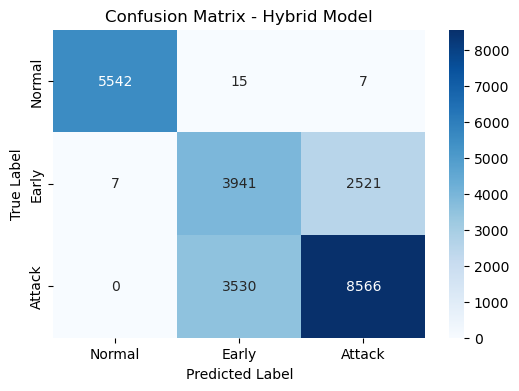

In [27]:
# Final Hierarchical Prediction
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

final_predictions = np.zeros_like(y_test_seq)

# Stage 1
stage1_pred = (model_stage1.predict(X_test_hybrid_new) > 0.5).astype(int).flatten()
final_predictions[stage1_pred == 0] = 0
attack_indices = np.where(stage1_pred == 1)[0]

if len(attack_indices) > 0:
    stage2_preds = np.argmax(
        model_stage2.predict(X_test_hybrid_new[attack_indices]),
        axis=1
    )
    final_predictions[attack_indices] = stage2_preds + 1

# Evaluation Metrics
cm = confusion_matrix(y_test_seq, final_predictions)
accuracy = accuracy_score(y_test_seq, final_predictions)

print("Accuracy:", round(accuracy*100,2), "%")

print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(
    y_test_seq,
    final_predictions,
    target_names=["Normal", "Early_DDoS", "Attack"]
))


# Confusion Matrix Plot
plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal","Early","Attack"],
    yticklabels=["Normal","Early","Attack"]
)
plt.title("Confusion Matrix - Hybrid Model")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [28]:
# GENERATE FINAL PREDICTIONS (MODEL 3 - HYBRID HIERARCHICAL)

print("\nGenerating Final Predictions using Model 3 - HYBRID HIERARCHICAL")
stage1_pred = (model_stage1.predict(X_test_hybrid_new, verbose=0) > 0.5).astype(int).flatten()

final_predictions_model3 = np.zeros_like(y_test_seq)
final_predictions_model3[stage1_pred == 0] = 0
attack_indices = np.where(stage1_pred == 1)[0]
if len(attack_indices) > 0:
    stage2_preds = np.argmax(
        model_stage2.predict(X_test_hybrid_new[attack_indices], verbose=0),
        axis=1
    )
    final_predictions_model3[attack_indices] = stage2_preds + 1

print("Prediction generation complete.")


Generating Final Predictions using Model 3 - HYBRID HIERARCHICAL
Prediction generation complete.


MULTI-CLASS ROC CURVE (Autoencoder + BiGRU Hybrid Model)


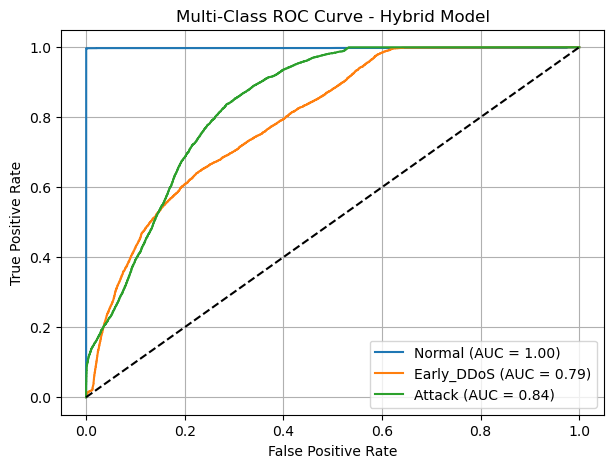


AUC Scores:
Normal AUC: 0.9976
Early_DDoS AUC: 0.7945
Attack AUC: 0.8408


In [29]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

print("MULTI-CLASS ROC CURVE (Autoencoder + BiGRU Hybrid Model)")

# Stage 1 probability
stage1_prob = model_stage1.predict(X_test_hybrid_new, verbose=0).flatten()

# Stage 2 probability (only for DDoS cases)
stage2_prob_full = np.zeros((len(X_test_hybrid_new), 2))

for i in range(len(X_test_hybrid_new)):
    if stage1_prob[i] > 0.5:
        stage2_prob_full[i] = model_stage2.predict(
            X_test_hybrid_new[i:i+1], verbose=0
        )[0]

y_pred_prob = np.zeros((len(X_test_hybrid_new), 3))
y_pred_prob[:, 0] = 1 - stage1_prob
y_pred_prob[:, 1] = stage1_prob * stage2_prob_full[:, 0]
y_pred_prob[:, 2] = stage1_prob * stage2_prob_full[:, 1]
y_test_bin = label_binarize(y_test_seq, classes=[0, 1, 2])

n_classes = 3
fpr, tpr, roc_auc = {}, {}, {}

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(7,5))

class_names = ["Normal", "Early_DDoS", "Attack"]

for i in range(n_classes):
    plt.plot(fpr[i], tpr[i],
             label=f"{class_names[i]} (AUC = {roc_auc[i]:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.title("Multi-Class ROC Curve - Hybrid Model")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()

print("\nAUC Scores:")
for i in range(n_classes):
    print(f"{class_names[i]} AUC: {roc_auc[i]:.4f}")

REAL-TIME SIMULATION (Autoencoder + BiGRU Hybrid Model)

First 20 Predictions vs Actual:
Actual: Early_DDoS | Predicted: Early_DDoS
Actual: Early_DDoS | Predicted: Early_DDoS
Actual: Early_DDoS | Predicted: Early_DDoS
Actual: Early_DDoS | Predicted: Early_DDoS
Actual: Early_DDoS | Predicted: Early_DDoS
Actual: Early_DDoS | Predicted: Early_DDoS
Actual: Early_DDoS | Predicted: Early_DDoS
Actual: Early_DDoS | Predicted: Early_DDoS
Actual: Early_DDoS | Predicted: Early_DDoS
Actual: Early_DDoS | Predicted: Early_DDoS
Actual: Early_DDoS | Predicted: Early_DDoS
Actual: Early_DDoS | Predicted: Early_DDoS
Actual: Early_DDoS | Predicted: Early_DDoS
Actual: Early_DDoS | Predicted: Early_DDoS
Actual: Early_DDoS | Predicted: Early_DDoS
Actual: Early_DDoS | Predicted: Early_DDoS
Actual: Early_DDoS | Predicted: Early_DDoS
Actual: Early_DDoS | Predicted: Early_DDoS
Actual: Early_DDoS | Predicted: Early_DDoS
Actual: Early_DDoS | Predicted: Early_DDoS

Confusion Matrix:
[[361  12   1]
 [  4 618 157]
 [

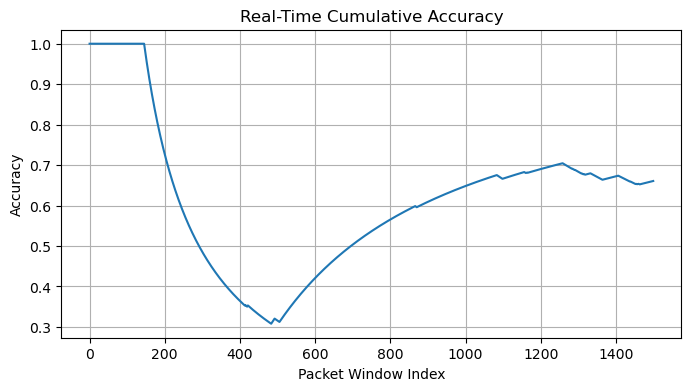

In [30]:
print("REAL-TIME SIMULATION (Autoencoder + BiGRU Hybrid Model)")

label_map = {0: "Normal", 1: "Early_DDoS", 2: "Attack"}

WINDOW_SIZE = X_test_hybrid_new.shape[1]
SIM_LEN = 1500
start_index = 0

X_stream = X_test_hybrid_new[start_index:start_index+SIM_LEN]
y_stream = y_test_seq[start_index:start_index+SIM_LEN]

predicted_labels = []

for i in range(len(X_stream)):

    stage1_p = model_stage1.predict(X_stream[i:i+1], verbose=0)[0][0]

    if stage1_p <= 0.5:
        predicted_labels.append(0)
    else:
        stage2_p = model_stage2.predict(X_stream[i:i+1], verbose=0)
        predicted_labels.append(np.argmax(stage2_p) + 1)

y_actual = y_stream
predicted_labels = np.array(predicted_labels)
print("\nFirst 20 Predictions vs Actual:")
for i in range(20):
    print(f"Actual: {label_map[y_actual[i]]} | Predicted: {label_map[predicted_labels[i]]}")

from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

print("\nConfusion Matrix:")
print(confusion_matrix(y_actual, predicted_labels))

print("\nClassification Report:")
print(classification_report(y_actual, predicted_labels))

print("\nAccuracy:", accuracy_score(y_actual, predicted_labels))

correct = (predicted_labels == y_actual).astype(int)
cumulative_accuracy = np.cumsum(correct) / np.arange(1, len(correct)+1)

plt.figure(figsize=(8,4))
plt.plot(cumulative_accuracy)
plt.title("Real-Time Cumulative Accuracy")
plt.xlabel("Packet Window Index")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

In [31]:
# PREVENTION MODULE SIMULATION (MODEL 3 - Autoencoder + BiGRU Hybrid Model)

print("PREVENTION MODULE SIMULATION (AI-based Defense - Autoencoder + BiGRU Hybrid Model)")

import numpy as np

BLOCK_COOLDOWN = 20
RATE_LIMIT_COOLDOWN = 10

blocked_ips = {}
rate_limited_ips = {}
alerts_log = []

SIM_LEN = min(SIM_LEN, len(X_stream))

if "Src_IP" in df_test_sorted.columns:
    ip_stream = df_test_sorted["Src_IP"].values[:SIM_LEN]
else:
    ip_stream = np.random.choice(
        ["192.168.1.10", "192.168.1.11", "10.0.0.5", "172.16.0.8"],
        SIM_LEN
    )
for t in range(SIM_LEN):
    current_ip = ip_stream[t]
    window_data = X_stream[t:t+1]   # IMPORTANT: already sequence-based
    stage1_p = model_stage1.predict(window_data, verbose=0)[0][0]

    if stage1_p <= 0.5:
        pred_label = 0
    else:
        stage2_p = model_stage2.predict(window_data, verbose=0)
        pred_label = np.argmax(stage2_p) + 1
        
    if current_ip in blocked_ips:
        if t - blocked_ips[current_ip] < BLOCK_COOLDOWN:
            action = "BLOCKED (Cooldown Active)"
        else:
            del blocked_ips[current_ip]
            action = "UNBLOCKED"

    elif current_ip in rate_limited_ips:
        if t - rate_limited_ips[current_ip] < RATE_LIMIT_COOLDOWN:
            action = "RATE LIMITED"
        else:
            del rate_limited_ips[current_ip]
            action = "RATE LIMIT REMOVED"

    else:
        if pred_label == 2:
            blocked_ips[current_ip] = t
            action = "BLOCK IP (ATTACK DETECTED)"

            alerts_log.append({
                "Time": t,
                "IP": current_ip,
                "Prediction": "Attack",
                "Action": "Blocked"
            })

        elif pred_label == 1:
            rate_limited_ips[current_ip] = t
            action = "APPLY RATE LIMIT (EARLY WARNING)"

            alerts_log.append({
                "Time": t,
                "IP": current_ip,
                "Prediction": "Early",
                "Action": "Rate Limited"
            })

        else:
            action = "ALLOW (Normal)"

    # Print first few logs
    if t < 20:
        print(f"Time={t}, IP={current_ip}, Prediction={label_map[pred_label]}, Action={action}")

print("PREVENTION MODULE SUMMARY")
print("Total Alerts Generated:", len(alerts_log))
print("Blocked IPs Active:", len(blocked_ips))
print("Rate-Limited IPs Active:", len(rate_limited_ips))

PREVENTION MODULE SIMULATION (AI-based Defense - Autoencoder + BiGRU Hybrid Model)
Time=0, IP=10.0.0.5, Prediction=Early_DDoS, Action=APPLY RATE LIMIT (EARLY WARNING)
Time=1, IP=172.16.0.8, Prediction=Early_DDoS, Action=APPLY RATE LIMIT (EARLY WARNING)
Time=2, IP=192.168.1.11, Prediction=Early_DDoS, Action=APPLY RATE LIMIT (EARLY WARNING)
Time=3, IP=192.168.1.10, Prediction=Early_DDoS, Action=APPLY RATE LIMIT (EARLY WARNING)
Time=4, IP=172.16.0.8, Prediction=Early_DDoS, Action=RATE LIMITED
Time=5, IP=192.168.1.10, Prediction=Early_DDoS, Action=RATE LIMITED
Time=6, IP=192.168.1.10, Prediction=Early_DDoS, Action=RATE LIMITED
Time=7, IP=10.0.0.5, Prediction=Early_DDoS, Action=RATE LIMITED
Time=8, IP=192.168.1.10, Prediction=Early_DDoS, Action=RATE LIMITED
Time=9, IP=192.168.1.10, Prediction=Early_DDoS, Action=RATE LIMITED
Time=10, IP=172.16.0.8, Prediction=Early_DDoS, Action=RATE LIMITED
Time=11, IP=172.16.0.8, Prediction=Early_DDoS, Action=RATE LIMIT REMOVED
Time=12, IP=172.16.0.8, Predi

In [32]:
import pandas as pd

if len(alerts_log) == 0:
    print("No alerts generated. Nothing to visualize.")
else:
    alerts_df = pd.DataFrame(alerts_log)
    print("Alerts dataframe created successfully.")
    print(alerts_df.head())

Alerts dataframe created successfully.
   Time            IP Prediction        Action
0     0      10.0.0.5      Early  Rate Limited
1     1    172.16.0.8      Early  Rate Limited
2     2  192.168.1.11      Early  Rate Limited
3     3  192.168.1.10      Early  Rate Limited
4    12    172.16.0.8      Early  Rate Limited


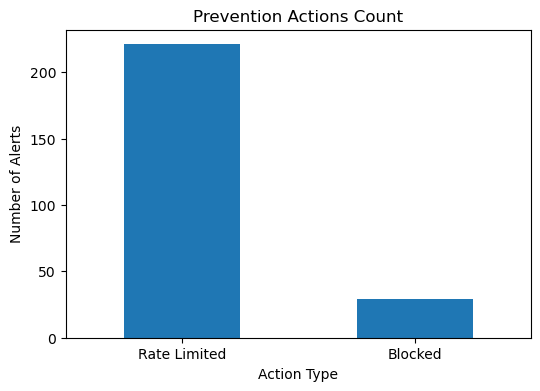

In [33]:
# Alert Action Count (Blocked vs Rate Limited)
import matplotlib.pyplot as plt

if len(alerts_log) == 0:
    print("No alerts to plot.")
else:
    plt.figure(figsize=(6,4))
    alerts_df["Action"].value_counts().plot(kind="bar")

    plt.title("Prevention Actions Count")
    plt.xlabel("Action Type")
    plt.ylabel("Number of Alerts")
    plt.xticks(rotation=0)
    plt.show()

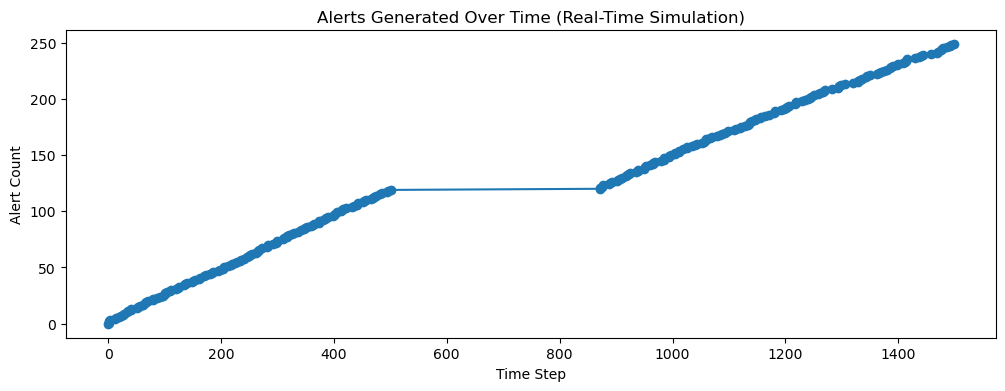

In [34]:
# Alerts Over Time (Real-Time Timeline)
import matplotlib.pyplot as plt

if len(alerts_log) == 0:
    print("No alerts to plot.")
else:
    plt.figure(figsize=(12,4))
    plt.plot(alerts_df["Time"], range(len(alerts_df)), marker="o")

    plt.title("Alerts Generated Over Time (Real-Time Simulation)")
    plt.xlabel("Time Step")
    plt.ylabel("Alert Count")
    plt.show()

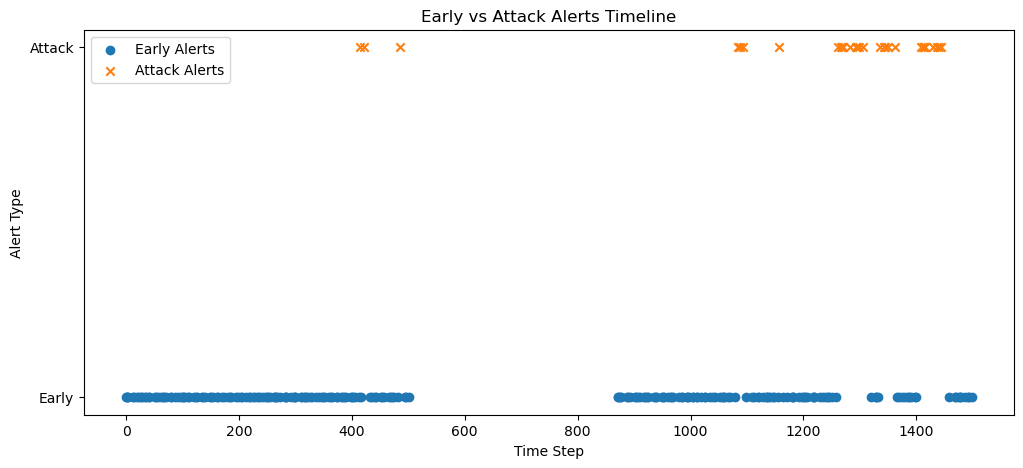

In [35]:
# Early vs Attack Alerts Timeline
import matplotlib.pyplot as plt

if len(alerts_log) == 0:
    print("No alerts to plot.")
else:
    early_alerts = alerts_df[alerts_df["Prediction"] == "Early"]
    attack_alerts = alerts_df[alerts_df["Prediction"] == "Attack"]

    plt.figure(figsize=(12,5))
    plt.scatter(early_alerts["Time"], [1]*len(early_alerts), 
                label="Early Alerts", marker="o")

    plt.scatter(attack_alerts["Time"], [2]*len(attack_alerts), 
                label="Attack Alerts", marker="x")

    plt.yticks([1,2], ["Early", "Attack"])
    plt.title("Early vs Attack Alerts Timeline")
    plt.xlabel("Time Step")
    plt.ylabel("Alert Type")
    plt.legend()
    plt.show()

In [36]:
import joblib
# Save Model 3 components
model_stage1.save("model3_stage1.keras")
model_stage2.save("model3_stage2.keras")
encoder.save("model3_encoder.keras")

joblib.dump(scaler, "scaler.pkl")
joblib.dump(scaler_encoded, "scaler_encoded.pkl")

print("Model 3 assets saved successfully!")

Model 3 assets saved successfully!


In [37]:
import os
os.getcwd()

'C:\\Users\\subha\\Capstone(DDoS) attack'

In [38]:
os.listdir()

['.ipynb_checkpoints',
 'ddos_gru_model.keras',
 'ddos_prevention_alerts.csv',
 'demo_attack_recovery.csv',
 'DNS-testing.parquet',
 'First try.ipynb',
 'LDAP-testing.parquet',
 'LDAP-training.parquet',
 'model3_encoder.keras',
 'model3_stage1.keras',
 'model3_stage2.keras',
 'MSSQL-testing.parquet',
 'MSSQL-training.parquet',
 'perfect_demo_attack_recovery.csv',
 'sample_dataset.xlsx',
 'scaler.pkl',
 'scaler_encoded.pkl',
 'stage2_bigru_early_attack.h5',
 'streamlit_test_data.csv',
 'Syn-testing.parquet',
 'Syn-training.parquet',
 'UDP-testing.parquet',
 'UDP-training.parquet',
 'Untitled.ipynb',
 'Untitled1.ipynb',
 'Untitled2.ipynb',
 'Untitled3.ipynb',
 'with 3 models (1st one).ipynb',
 'with 3 models.ipynb']

In [39]:
import pandas as pd

# Load your existing test dataset
df = pd.read_csv("streamlit_test_data.csv")

# Shuffle to avoid ordering bias
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# Create attack-heavy and normal-heavy splits
attack_candidates = df[df["Flow Packets/s"] > df["Flow Packets/s"].quantile(0.75)]
normal_candidates = df[df["Flow Packets/s"] < df["Flow Packets/s"].quantile(0.25)]

# Sample fixed-size segments
normal_part = normal_candidates.sample(2000, random_state=42)
attack_part = attack_candidates.sample(4000, random_state=42)
recovery_part = normal_candidates.sample(2000, random_state=24)

# Combine into attack → recovery pattern
demo_df = pd.concat([normal_part, attack_part, recovery_part], ignore_index=True)

# Save new demo file
demo_df.to_csv("demo_attack_recovery.csv", index=False)

print("Demo CSV created successfully!")

Demo CSV created successfully!


In [40]:
import pandas as pd
import numpy as np

# Load original test dataset
df = pd.read_csv("streamlit_test_data.csv")

# Load your trained model components (same as Streamlit)
import tensorflow as tf
import joblib

stage1_model = tf.keras.models.load_model("model3_stage1.keras")
stage2_model = tf.keras.models.load_model("model3_stage2.keras")
encoder = tf.keras.models.load_model("model3_encoder.keras")
scaler = joblib.load("scaler.pkl")
scaler_encoded = joblib.load("scaler_encoded.pkl")

WINDOW_SIZE = 30

# Use your same selected_features list here
selected_features = traffic_features = [
    'Flow Packets/s','Flow Bytes/s','Total Fwd Packets','Total Backward Packets',
    'Fwd Packets/s','Bwd Packets/s','Down/Up Ratio'
]

duration_features = [
    'Flow Duration','Active Mean','Active Std','Active Max','Active Min',
    'Idle Mean','Idle Std','Idle Max','Idle Min'
]

iat_features = [
    'Flow IAT Mean','Flow IAT Std','Flow IAT Max','Flow IAT Min',
    'Fwd IAT Mean','Fwd IAT Std','Bwd IAT Mean','Bwd IAT Std'
]

tcp_flag_features = [
    'SYN Flag Count','ACK Flag Count','RST Flag Count','PSH Flag Count','FIN Flag Count'
]

packet_features = [
    'Packet Length Mean','Packet Length Std','Packet Length Variance',
    'Packet Length Min','Packet Length Max','Avg Packet Size',
    'Avg Fwd Segment Size','Avg Bwd Segment Size'
]

subflow_features = [
    'Subflow Fwd Packets','Subflow Fwd Bytes',
    'Subflow Bwd Packets','Subflow Bwd Bytes'
]

selected_features = (
    traffic_features + duration_features + iat_features +
    tcp_flag_features + packet_features + subflow_features
)

# Preprocess
X_raw = df[selected_features].copy()
X_scaled = scaler.transform(X_raw)
X_scaled = np.array(X_scaled).astype(np.float32)

# Create sequences
X_seq = []
for i in range(len(X_scaled) - WINDOW_SIZE):
    X_seq.append(X_scaled[i:i+WINDOW_SIZE])
X_seq = np.array(X_seq)

# Hybrid prediction
n_samples, timesteps, n_features = X_seq.shape
X_reshaped = X_seq.reshape(-1, n_features)

encoded = encoder.predict(X_reshaped, verbose=0)
encoded_scaled = scaler_encoded.transform(encoded)
encoded_seq = encoded_scaled.reshape(n_samples, timesteps, -1)

X_combined = np.concatenate([X_seq, encoded_seq], axis=2)

stage1_probs = stage1_model.predict(X_combined, verbose=0)
stage1_labels = (stage1_probs > 0.5).astype(int).flatten()

final_labels = []

for i in range(len(stage1_labels)):
    if stage1_labels[i] == 0:
        final_labels.append(0)
    else:
        stage2_prob = stage2_model.predict(X_combined[i:i+1], verbose=0)
        stage2_label = np.argmax(stage2_prob)
        final_labels.append(stage2_label + 1)

final_labels = np.array(final_labels)

# Now separate rows based on ACTUAL MODEL PREDICTION
normal_indices = np.where(final_labels == 0)[0]
attack_indices = np.where(final_labels == 2)[0]

# Select clean segments
normal_part1 = df.iloc[normal_indices[:2000]]
attack_part = df.iloc[attack_indices[:2000]]
normal_part2 = df.iloc[normal_indices[2000:4000]]

demo_df = pd.concat([normal_part1, attack_part, normal_part2])
demo_df.to_csv("perfect_demo_attack_recovery.csv", index=False)

print("Perfect demo dataset created!")

Perfect demo dataset created!
